## Word embeddings
*(Credit: Leon Derczynski, IT University of Copenhagen)*

Last updated May 2025

Let's load some embeddings, and then use these to see which words are close to each other.
We'll use the gensim package's word2vec implementation, and an nltk corpus. We also need to download punkt - an nltk tokeniser used by the movie_reviews corpus. And we'll use seaborn to visualise embeddings as heatmaps

In [ ]:
# We will install gensim, a Python language modelling library
# that includes some embedding model implementations
!pip install --upgrade gensim

# At the time of writing, there was a bug in gensim. It can
# be worked round by restarting your colab runtime. We do it
# in code here, using the os (operating system) package and the
# its kill method.
import os
os.kill(os.getpid(), 9)

In [1]:
# Now let's import Word2Vec from gensim
from gensim.models import Word2Vec

# We will use some text corpora from nltk
from nltk.corpus import brown, movie_reviews
import nltk
nltk.download('brown')
nltk.download('movie_reviews')
nltk.download('punkt_tab')

# We'll use seaborn to visualise embeddings as heatmaps
import seaborn as sns

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Let's generate word vectors over the Brown corpus text. We will have 20 dimensions, using a window of three for the context words in the skip-grams (e.g. c1, c2, w, c3, c4). This might be a little slow (maybe 1-2 minutes).

In [2]:
# for the Brown corpus
b = Word2Vec(brown.sents(), vector_size=20, window=3, min_count=3)

Now we have the vectors, we can see how good they are by measuring which words are similar to each other.

In [3]:
b.wv.most_similar('company', topn=5)

[('pool', 0.9647120833396912),
 ('imagination', 0.9488083720207214),
 ('family', 0.9473740458488464),
 ('nation', 0.946887195110321),
 ('crowd', 0.9435063600540161)]

Not great, eh? Try altering the window and the dimension size, to see if you get better results.

Try also with the movie reviews results!

In [4]:
# for the movie review corpus
mr = Word2Vec(movie_reviews.sents(), vector_size=20, window=5, min_count=3)

In [5]:
mr.wv.most_similar('love', topn=5)

[('suspect', 0.7063999772071838),
 ('urinate', 0.706067681312561),
 ('immediately', 0.6941218972206116),
 ('living', 0.692712128162384),
 ('flamboyantly', 0.6905128359794617)]

We can also do some arithmetic with the words. Let's try that classical result, king - man + woman.

In [6]:
b.wv.most_similar(positive=['biggest', 'small'], negative=['big'], topn=5)

[('cultivation', 0.9390923380851746),
 ('tax', 0.9359056949615479),
 ('extant', 0.9357916712760925),
 ('product', 0.935340404510498),
 ('activity', 0.9341930150985718)]

Not a perfect result with the default model! Why don't we try loading a bigger dataset, based on a bigger vocabulary. This should give better results. You'll need the GloVe embeddings for this.

We will download this from a github repository. If you are running this on your own local computer (rather then Colaboratory) you can download from www.derczynski.com/glove.twitter.27B.25d.txt.bz2 to your machine. In this case, there is no need to run the next cell - just replace the file name in the cell after next with the path to your downloaded file.

In [7]:
!git clone --quiet https://github.com/KCL-Health-NLP/nlp_examples.git
from gensim.models.keyedvectors import KeyedVectors
print("Done copying files")

fatal: destination path 'nlp_examples' already exists and is not an empty directory.
Done copying files


Now let's load the model file. This might take a few minutes. If you are using a copy on your own local machine, change the file path below to that of your file.

In [8]:
glove = KeyedVectors.load_word2vec_format("nlp_examples/representation/glove.twitter.27B.25d.txt.bz2", binary=False)
print("Done loading")

Done loading


Now, try the above again. Can you find any cool word combinations? What differences are there in the datasets?

Here are some ideas to try, substitute your own words in to these.

In [9]:
glove.most_similar('meat', topn=5)

[('bread', 0.9616428017616272),
 ('corn', 0.9524653553962708),
 ('egg', 0.9472205638885498),
 ('fish', 0.9398375153541565),
 ('soup', 0.927527666091919)]

In [10]:
glove.most_similar(positive=['biggest', 'small'], negative=['big'], topn=5)

[('average', 0.8820492625236511),
 ('human', 0.8792450428009033),
 ('persons', 0.8779707551002502),
 ('smallest', 0.8638321757316589),
 ('potential', 0.8624013066291809)]

In [11]:
glove.most_similar(positive=['woman', 'king'], negative=['man'])

[('meets', 0.8841923475265503),
 ('prince', 0.832163393497467),
 ('queen', 0.8257461190223694),
 ('’s', 0.8174097537994385),
 ('crow', 0.813499391078949),
 ('hunter', 0.8131037950515747),
 ('father', 0.8115833401679993),
 ('soldier', 0.81113600730896),
 ('mercy', 0.8082392811775208),
 ('hero', 0.8082262277603149)]

In [12]:
glove.similarity('car', 'bike')

np.float32(0.77646494)

In [13]:
glove.similarity('car', 'purple')

np.float32(0.6448954)

In [14]:
glove.similarity('red', 'purple')

np.float32(0.86647636)

In [15]:
glove.doesnt_match("breakfast cereal dinner lunch".split())

'cereal'

In [16]:
glove.doesnt_match("red green horse blue".split())

'horse'

What about ambiguous words? Can you think of any and try them? Past suggestions have been cancer, bank and play. Can you find any others, and explain what is going on? How does the embedding deal with ambiguity? What factors influence this?

In [17]:
glove.most_similar('word')

[('kind', 0.9247308969497681),
 ('even', 0.8885588049888611),
 ('is', 0.87043297290802),
 ('over', 0.8653794527053833),
 ('blind', 0.8579868078231812),
 ('exactly', 0.8571450710296631),
 ('its', 0.8565130829811096),
 ('had', 0.8532354235649109),
 ('true', 0.8527782559394836),
 ('exact', 0.8523545265197754)]

What do these embeddings look like? We will display embeddings for four words: two colour adjectives, and two action verbs. Each column is the enbedding for one word. We have printed to two decimal places, using Python string formatting. Can you spot any similarities and differences?

In [18]:
print("   red      green             walk    run\n")
for i in range(len(glove['red'])):
  print("%8.2f%8.2f          %8.2f%8.2f" % (glove['red'][i], glove['green'][i], glove['walk'][i], glove['run'][i]))

   red      green             walk    run

   -0.27   -0.68             -1.41   -0.03
   -0.73   -0.91              0.28    0.49
    0.55    0.21              0.52    0.17
   -0.30   -0.12              0.23   -0.21
    0.29   -0.22             -0.85   -0.32
    0.80    0.70              0.55    0.46
    0.63    0.75              1.26    1.15
    0.64   -0.25             -0.66   -0.32
   -0.11    0.66              0.53    0.32
   -0.32   -0.19              0.44    0.13
    1.02    0.95             -0.60    0.01
   -0.62   -0.33              0.21    0.17
   -4.04   -4.08             -4.41   -4.05
   -0.31   -0.73              0.28    0.27
   -0.36   -0.11             -0.20    0.35
   -0.30   -0.97              0.63   -0.03
    0.48    0.49              0.18    0.00
   -0.32   -0.28             -0.67   -0.82
    0.39    0.39             -0.10   -0.24
    0.82    0.99             -1.07   -0.69
   -0.84   -0.83              0.02   -0.30
    0.04   -0.05              0.17    0.30
    0.73   

Let's visualise this as a heatmap, using seaborn (imported as sns)

<Axes: >

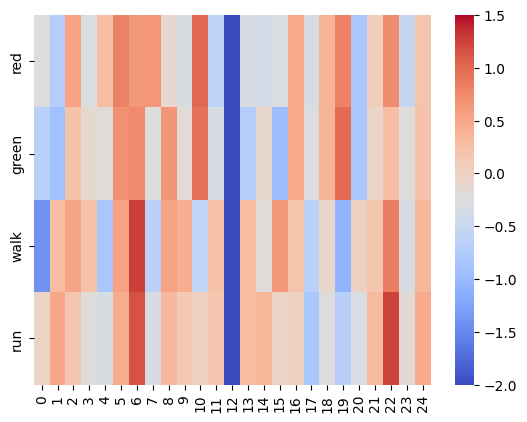

In [19]:

sns.heatmap([glove['red'], glove['green'], glove['walk'], glove['run']],
            cmap = 'coolwarm', vmin = -2, vmax = 1.5,
            yticklabels=['red', 'green', 'walk', 'run'])

How do we use these embeddings in NLP? The usual way is to replace each occurence of a word with an embedding - it represents our word. The example below displays what we would pass to our algorithm for a sentence. We show one line for each word, with each value formatted to two decimal places again. The word is displayed at the start of the line for convenience only - this would not be passed to our algorithm.

In [20]:
sentence=["the", "quick", "brown", "fox", "jumped", "over", "the", "lazy", "dog"]
embeddings = []
for i in sentence:
  embeddings.append(glove[i])

for i, val in enumerate(embeddings):
  print(sentence[i].ljust(10), ''.join("{:6.2f}".format(x) for x in val))


the         -0.01  0.02  0.21  0.17 -0.44 -0.15  1.84 -0.16  0.18 -0.32  0.07  0.52 -6.34  0.48  0.14 -0.49  0.39 -0.00 -0.10  0.21 -0.86  0.17  0.19 -0.84 -0.31
quick       -0.06  1.14 -0.49  0.09  0.57  0.64  0.96 -0.88  0.29 -0.31 -0.26  0.72 -3.54 -0.52  0.40  0.13  0.45 -1.03 -0.58 -0.79 -0.30 -0.47  0.98  0.29 -0.36
brown       -0.55 -0.93  0.71  0.31 -0.15  0.39  0.46  0.08  0.33 -1.07  0.72  0.14 -3.99 -1.25 -0.13 -0.57 -0.32 -0.36 -0.41  0.78  0.21  0.93  0.37 -0.44 -0.09
fox          0.32 -0.05  0.90 -0.50  0.14 -0.48  0.40  0.51  0.32 -0.81  0.42 -0.49 -3.01 -0.40  0.57 -0.45 -0.60  0.28 -0.07  0.20  0.22  0.10 -0.15 -1.32  0.11
jumped      -1.01  0.55  1.84 -0.24 -0.56 -0.08  0.32 -1.00 -0.37  0.67  0.45  1.24 -2.95  0.23  0.16  0.76  0.95 -0.04  0.09 -0.87  0.85  0.56  2.15 -0.91 -0.27
over         0.55  0.34 -0.05  0.03 -0.59  0.23  0.10 -0.60 -1.03  0.67  0.19  1.27 -5.16  0.18  0.38  0.74  0.38  0.52 -0.79 -0.45 -0.78  0.23  0.19 -0.47  0.39
the         -0.01  0.02  0.2